In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:13pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

In [5]:
import pandas as pd
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로직스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

### # 1. csv파일을 데이터프레임으로 읽어오기(걸측치처리, 타겍변수 균형확인 용이) => 넘파이 배열로 변환 => 데이터 분활

In [5]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
df.sample()

,0,1,2,3,4,5,6,7,8
743,9,140,94,0,0,32.7,0.734,45,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info() # 결측치 없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.isna().sum() # 열별 결측치 갯수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [11]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [12]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

### # 2. csv파일을 넘파이배열 읽어오기 => 데이터 분할
- np.loadtxt()

In [6]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', 
                      encoding='utf-8',
                      delimiter=',',
                      #comments='#'
                      )
dataset.shape

(768, 9)

In [7]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:620, :-1]
y_train = dataset[:620, -1]
X_test  = dataset[620:, :-1]
y_test  = dataset[620:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

# 2. 모델 구성

In [47]:
model = Sequential()
#model.add(Dense(64, input_shape=(8,),
#               activation='relu'))
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # 이진분류(로지스틱회귀분석)의 출력층 활성화함수
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 32)                288       
                                                                 
 dense_13 (Dense)            (None, 64)                2112      
                                                                 
 dense_14 (Dense)            (None, 16)                1040      
                                                                 
 dense_15 (Dense)            (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [10]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습

In [11]:
%%time
hist = model.fit(X_train, y_train, # 훈련(학습)데이터셋
                 epochs=200,
                 batch_size=310,
                 # validation_data=(X_val, y_val) 검증데이터셋
                 validation_split=0.1, # 검증데이터 비율(훈련데이터셋에서 10%는 검증데이터셋으로)
                 verbose=0 # 학습과정 로그 출력 안함
                )

CPU times: total: 23.5 s
Wall time: 24.3 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼돈매트릭스, 성능평가지표) 그리기

In [26]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

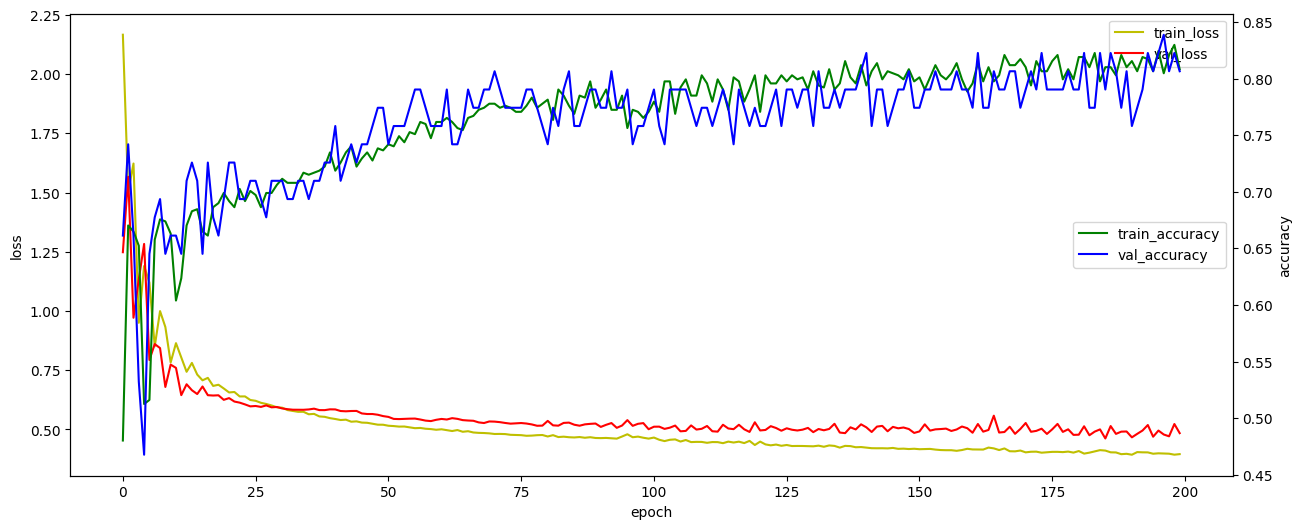

In [12]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

### ▶ 틀린 방법

In [15]:
model.evaluate(X_train, y_train, 
               #batch_size=310
              )

20/20 [==============================] - 0s 7ms/step - loss: 0.4010 - accuracy: 0.8226


[0.40097305178642273, 0.8225806355476379]

### ▶ 옳은방법

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100}')

5/5 [==============================] - 0s 9ms/step - loss: 0.5729 - accuracy: 0.7365
정확도 : 73.64864945411682


In [20]:
# 교차표(혼돈행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)
# y_test : 1차원
# y_hat : 2차원

5/5 [==============================] - 0s 3ms/step


In [22]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
#    print(y, h)
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

77 19
20 32


In [29]:
ctab = pd.crosstab(y_test.astype(int), # 실제
            y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1),
           rownames=['실제값'],
           colnames=['예측값']) # 결과가 데이터프레임

예측값,0,1
실제값,,
0,77,19
1,20,32


In [26]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy배열인 혼동행렬

array([[77, 19],
       [20, 32]], dtype=int64)

In [27]:
precision = 26 / (15+26)
recall = 26 / (26+26)
print('recall : ', recall)
print('precision :', precision)

recall :  0.5
precision : 0.6341463414634146


## 6. 모델 사용( 예측 / 저장)

In [31]:
# 모델저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model, 'model/05_pima.h5')

In [32]:
# 저장한 모델 load
model2 = load_model('model/05_pima.h5')

In [33]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [37]:
# 예측하기
(model.predict([[2, 112,86,42,160,38.4,0.246,28]])>0.5).astype(int)

1/1 [==============================] - 0s 40ms/step


array([[0]])

In [38]:
(model.predict([[2, 112,86,42,160,38.4,0.246,28],
               [6,148,72,35,0,33.6,0.627,50]
               ])>0.5).astype(int)

1/1 [==============================] - 0s 43ms/step


array([[0],
       [0]])

# 분류분석
1. 데이터 생성 및 전처리 : 훈련셋 600, 검증셋100, 테스트셋68로 분리. 타겟변수의 원핫인코딩
2. 모델 생성(input8, output1) - 출력층의 활성화함수 softmax
3. 모델 학습 과정 loss = 'categorical_crossentropy' metrics=['accuracy']
4. 모델 학습 validation_data = (X_val, y_val)
5. 모델 학습 평가
6. 모델 사용
   model.predict(input_data).argma()

## 1. 데이터셋 생성 및 전처리

In [39]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
dataset = df.values

In [40]:
# 훈련셋 600, 검증셋100, 테스트셋68
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val   = dataset[600:700, :-1]
y_val   = dataset[600:700, -1]
X_test  = dataset[700:, :-1]
y_test  = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [43]:
# 원핫인코딩 ( 0 : 1 0 / 1 : 0 1 )
Y_train = utils.to_categorical(y_train, num_classes=2) # pd.get_dummies(y_train).values
Y_val   = utils.to_categorical(y_val, 2)
Y_test  = utils.to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

In [44]:
print('원데이터 :', y_train[:3])
print('원핫인코딩 데이터 : \n', Y_train[:3])

원데이터 : [1. 0. 1.]
원핫인코딩 데이터 : 
 [[0. 1.]
 [1. 0.]
 [0. 1.]]


## 2. 모델생성(input8->target2)

In [48]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=2, activation='softmax')) # 이진분류(로지스틱회귀분석)의 출력층 활성화함수
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 32)                288       
                                                                 
 dense_17 (Dense)            (None, 64)                2112      
                                                                 
 dense_18 (Dense)            (None, 16)                1040      
                                                                 
 dense_19 (Dense)            (None, 2)                 34        
                                                                 
Total params: 3,474
Trainable params: 3,474
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [51]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'])

## 4. 모델 학습

In [52]:
hist = model.fit(X_train,Y_train,
                epochs=200,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/200
19/19 [==============================] - 1s 19ms/step - loss: 2.5708 - accuracy: 0.4883 - val_loss: 1.3259 - val_accuracy: 0.6500
Epoch 2/200
19/19 [==============================] - 0s 11ms/step - loss: 1.6047 - accuracy: 0.5383 - val_loss: 0.9699 - val_accuracy: 0.5500
Epoch 3/200
19/19 [==============================] - 0s 11ms/step - loss: 1.3274 - accuracy: 0.5917 - val_loss: 1.2578 - val_accuracy: 0.5900
Epoch 4/200
19/19 [==============================] - 0s 11ms/step - loss: 0.9124 - accuracy: 0.6350 - val_loss: 1.0606 - val_accuracy: 0.6500
Epoch 5/200
19/19 [==============================] - 0s 11ms/step - loss: 0.8875 - accuracy: 0.6467 - val_loss: 0.9482 - val_accuracy: 0.5800
Epoch 6/200
19/19 [==============================] - 0s 13ms/step - loss: 1.2135 - accuracy: 0.6083 - val_loss: 0.8879 - val_accuracy: 0.5600
Epoch 7/200
19/19 [==============================] - 0s 12ms/step - loss: 0.9995 - accuracy: 0.6267 - val_loss: 1.3202 - val_accuracy: 0.4500
Epoch 

19/19 [==============================] - 0s 6ms/step - loss: 0.5106 - accuracy: 0.7600 - val_loss: 0.5211 - val_accuracy: 0.7300
Epoch 59/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4984 - accuracy: 0.7750 - val_loss: 0.5421 - val_accuracy: 0.7700
Epoch 60/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4814 - accuracy: 0.7717 - val_loss: 0.5023 - val_accuracy: 0.7800
Epoch 61/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4792 - accuracy: 0.7783 - val_loss: 0.5625 - val_accuracy: 0.7700
Epoch 62/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4677 - accuracy: 0.7600 - val_loss: 0.5312 - val_accuracy: 0.7900
Epoch 63/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4623 - accuracy: 0.7750 - val_loss: 0.5399 - val_accuracy: 0.7200
Epoch 64/200
19/19 [==============================] - 0s 8ms/step - loss: 0.5465 - accuracy: 0.7483 - val_loss: 0.7059 - val_accuracy: 0.6900
Epoch 65/200
19/19 

19/19 [==============================] - 0s 7ms/step - loss: 0.4061 - accuracy: 0.8050 - val_loss: 0.4899 - val_accuracy: 0.7800
Epoch 116/200
19/19 [==============================] - 0s 10ms/step - loss: 0.4766 - accuracy: 0.7633 - val_loss: 0.6005 - val_accuracy: 0.7600
Epoch 117/200
19/19 [==============================] - 0s 9ms/step - loss: 0.4863 - accuracy: 0.7733 - val_loss: 0.5682 - val_accuracy: 0.7900
Epoch 118/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4351 - accuracy: 0.8017 - val_loss: 0.6987 - val_accuracy: 0.6800
Epoch 119/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4286 - accuracy: 0.7867 - val_loss: 0.6160 - val_accuracy: 0.7800
Epoch 120/200
19/19 [==============================] - 0s 8ms/step - loss: 0.4207 - accuracy: 0.8167 - val_loss: 0.5623 - val_accuracy: 0.8000
Epoch 121/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4207 - accuracy: 0.7917 - val_loss: 0.5399 - val_accuracy: 0.7600
Epoch 122/20

19/19 [==============================] - 0s 7ms/step - loss: 0.4258 - accuracy: 0.8000 - val_loss: 0.5424 - val_accuracy: 0.7400
Epoch 173/200
19/19 [==============================] - 0s 8ms/step - loss: 0.3934 - accuracy: 0.8233 - val_loss: 0.5784 - val_accuracy: 0.7800
Epoch 174/200
19/19 [==============================] - 0s 6ms/step - loss: 0.3988 - accuracy: 0.8267 - val_loss: 0.5682 - val_accuracy: 0.7600
Epoch 175/200
19/19 [==============================] - 0s 7ms/step - loss: 0.4068 - accuracy: 0.8250 - val_loss: 0.5907 - val_accuracy: 0.7600
Epoch 176/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4381 - accuracy: 0.7917 - val_loss: 0.7124 - val_accuracy: 0.7000
Epoch 177/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4258 - accuracy: 0.8083 - val_loss: 0.6024 - val_accuracy: 0.7400
Epoch 178/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4019 - accuracy: 0.8300 - val_loss: 0.6336 - val_accuracy: 0.7400
Epoch 179/200

## 4. 모델 학습

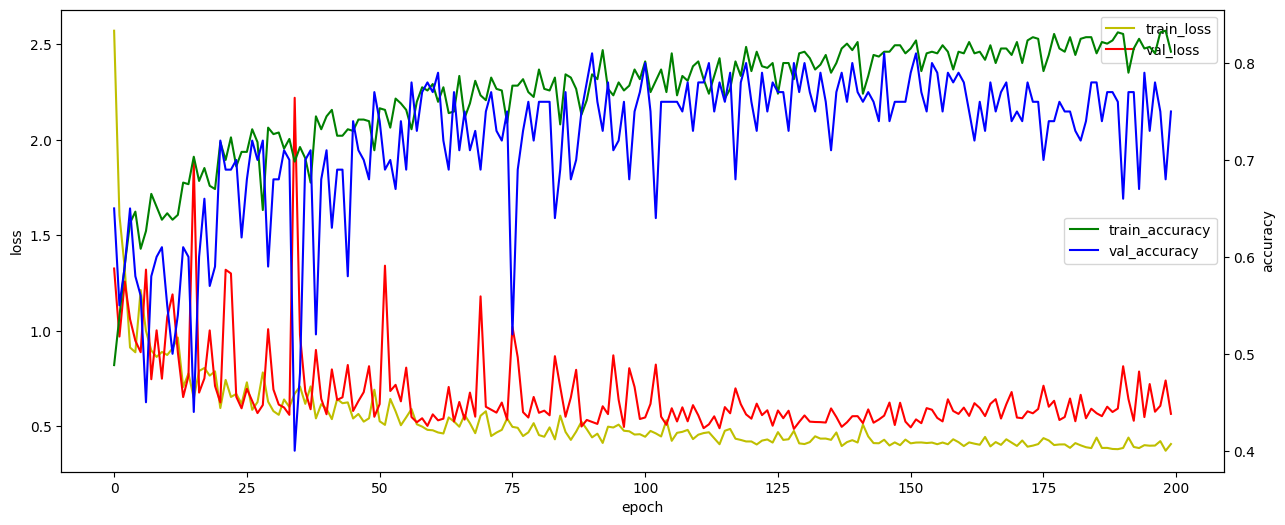

In [53]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [54]:
# 모델 평가
loss, accuracy = model.evaluate(X_test, Y_test)
accuracy

3/3 [==============================] - 0s 8ms/step - loss: 0.7399 - accuracy: 0.6912


0.6911764740943909

In [58]:
# 혼동행렬==교차표를 위한 y_test의 예측값
y_hat = model.predict(X_test).argmax(axis=1) # 예측값 / 실제값 y_hat
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 5ms/step


((68,), (68,))

In [59]:
# 교차표(데이터 프레임)
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,38,3
1.0,18,9


In [60]:
# 혼동행렬(numpy배열)
confusion_matrix(y_test, y_hat)

array([[38,  3],
       [18,  9]], dtype=int64)

## 6. 모델 사용(예측)

In [61]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [66]:
model.predict([[2,122,76,27,200,35.9,0.483,26]]).argmax(axis=1)

1/1 [==============================] - 0s 87ms/step


array([0], dtype=int64)

In [67]:
df

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
